# SSH Security & Authentication Analytics (Splunk SIEM Project)

**Security Engineer:** Engineer Muhammad Usman Akram  
**Tool / Platform:** Splunk Enterprise / SIEM  
**Data Domain:** Network & SSH Log Security Analytics  

---

## Project Description

In modern enterprise IT and cybersecurity environments, Secure Shell (SSH) is one of the most critical remote management protocols. However, because it grants privileged system access, SSH services are constantly targeted by brute-force attacks, unauthorized access attempts, password spraying, and network reconnaissance.

This project delivers an end-to-end **SSH Security & Authentication Analytics Solution** built using **Splunk Enterprise**. The solution ingests structured SSH connection logs, extracts essential security features, visualizes operational and security metrics via a comprehensive interactive dashboard, and establishes automated real-time alert triggers to detect malicious anomalies and attack vectors.

---

## Dataset Overview & Schema Architecture

The dataset used in this project consists of detailed SSH event logs capturing both network-layer metrics and application-layer authentication events.

### Dataset Details
* **Log Source Type:** SSH / Network Connection Logs (Zeek/Bro SSH Log Format)
* **Total Event Records:** 1,200 Events
* **Data Splitting Strategy (80/20 Rule):**
  * **80% Baseline Dataset (960 Events):** Ingested initially into the Splunk index (`ssh_logs`) to perform historical baseline analysis, build visual analytics charts, and configure security alerts.
  * **20% Testing Dataset (240 Events):** Retained and subsequently ingested into the active index to simulate live incoming data, validating whether configured Splunk Security Alerts trigger as expected during real-time threat detection.

### Dataset Field Dictionary

| Field Name | Data Type | Description |
| :--- | :--- | :--- |
| `_time` | Timestamp | Date and time when the SSH event was recorded. |
| `id_orig_h` | String (IP) | Source / Client IP address initiating the SSH connection. |
| `id_orig_p` | Integer | Source port number on the client machine. |
| `id_resp_h` | String (IP) | Destination / Server IP address receiving the SSH connection. |
| `id_resp_p` | Integer | Destination port on the target server (Standard: 22). |
| `username` | String | User identity/account name attempted during authentication. |
| `auth_success` | Boolean / Num | Authentication outcome (`true`/`1.0` for success, `false`/`0.0` for failure). |
| `auth_attempts` | Integer | Number of authentication attempts within a single connection session. |
| `event_type` | String | Categorization of the event (e.g., *Successful SSH Login*, *Failed SSH Login*, *Multiple Failed Authentication Attempts*, *Connection Without Authentication*). |
| `conn_state` | String | TCP Connection state code (e.g., `SF` for normal established/closed, `REJ` for rejected). |
| `orig_pkts` | Integer | Total count of network packets sent by the origin (client) IP. |
| `orig_ip_bytes` | Integer | Total byte volume transmitted by the origin (client) IP. |

---

## Executive Summary

This report provides an overview of SSH security and authentication analytics, leveraging insights derived from Splunk Enterprise. Our analysis focuses on identifying and mitigating common SSH-related threats such as brute-force attacks, unauthorized access attempts, password spraying, and network reconnaissance.

Through continuous monitoring and the implementation of 10 distinct security alerts, we have established a robust detection framework. Key alerts are configured to detect:

*   **Brute-Force Attacks:** Triggered by multiple failed login attempts from a single source IP.
*   **Targeting of Privileged Accounts:** Immediate alerts for attempts against 'root' or 'admin' accounts.
*   **High Authentication Attempt Anomalies:** Identifying dictionary attacks where a single client attempts more than 3 password credentials within a session.
*   **Unusual Nighttime Access:** Flagging login attempts during off-peak hours.
*   **Potential Password Spraying:** Detecting single source IPs attempting logins against multiple distinct usernames.
*   **Login Success After Failures:** Highlighting successful authentications following previous failures, indicating potential account breaches.
*   **High Packet Count Sessions:** Identifying abnormally heavy network traffic that could signal data exfiltration or fuzzing.
*   **Admin/Service Account Access:** Monitoring attempts on sensitive service accounts.
*   **Non-Authenticated Connections:** Detecting sessions that terminate before authentication.
*   **Distributed Connection Activity:** Flagging target servers receiving connections from numerous unique source IPs.

These proactive alerts are crucial for real-time threat detection, enabling swift response to potential security incidents and enhancing the overall resilience of our SSH infrastructure against sophisticated cyber threats.

## Splunk Security Dashboard & Analytics Charts

Below are the 20 visual analytics panels configured on the **SSH Security & Authentication Analytics Dashboard**. Each chart includes its title, description, Splunk Search Processing Language (SPL) query in code blocks, and reference image tag.


## Resources


### Chart 01: Total SSH Log Events Count
* **Description:** Displays the overall count of all recorded SSH activity events in the ingested dataset baseline.
* **SPL Query:**
```spl
index="ssh_logs" | stats count


### Chart 02: Successful SSH Logins
*   **Description:** Total count of successfully authenticated SSH sessions across the environment.
*   **SPL Query:**
```spl
index="ssh_logs" (auth_success="true" OR auth_success=1) | stats count
```

### Chart 03: Total Failed Login Attempts
*   **Description:** Total number of unsuccessful SSH login attempts, indicating brute-force or unauthorized access attempts.
*   **SPL Query:**
```spl
index="ssh_logs" (auth_success="false" OR auth_success=0) | stats count
```

### Chart 04: Other System & Session Events
*   **Description:** Tracks operational SSH events such as session disconnects, key exchanges, and connection closures.
*   **SPL Query:**
```spl
index="ssh_logs" NOT auth_success=* | stats count
```

### Chart 05: SSH Event Types Distribution
*   **Description:** Categorizes and displays the distribution of primary operational and security event types recorded in the dataset.
*   **SPL Query:**
```spl
index="ssh_logs" | top limit=10 event_type
```

### Chart 06: Authentication Status Over Time
*   **Description:** Compares successful connections against failed ones across time intervals to observe trend spikes.
*   **SPL Query:**
```spl
index="ssh_logs" | timechart count by auth_success
```

### Chart 07: Unique Source IP Addresses
*   **Description:** Total number of distinct client IP addresses attempting to connect via SSH.
*   **SPL Query:**
```spl
index="ssh_logs" | stats dc(id_orig_h) as unique_ips
```

### Chart 08: Top 10 Source IPs by Volume
*   **Description:** Identifies the top client IP addresses generating the highest volume of SSH connection requests.
*   **SPL Query:**
```spl
index="ssh_logs" | top limit=10 id_orig_h
```

### Chart 09: Top 10 Targeted Usernames
*   **Description:** Highlights usernames most frequently targeted by automated scripts or malicious attackers.
*   **SPL Query:**
```spl
index="ssh_logs" | top limit=10 username
```

### Chart 10: Unique Targeted Usernames
*   **Description:** Counts distinct usernames targeted during SSH connection attempts.
*   **SPL Query:**
```spl
index="ssh_logs" | stats dc(username) as unique_users
```

### Chart 11: Privileged Account Attacks
*   **Description:** Counts access attempts against superuser or administrative accounts (e.g., root, admin).
*   **SPL Query:**
```spl
index="ssh_logs" (username="root" OR username="admin" OR username="sysadmin") | stats count
```

### Chart 12: Top Suspicious IPs (Failed Logins)
*   **Description:** Highlights source IPs responsible for the highest number of failed authentication attempts.
*   **SPL Query:**
```spl
index="ssh_logs" (auth_success="false" OR auth_success=0) | top limit=10 id_orig_h
```

### Chart 13: Destination Ports Targeted
*   **Description:** Analyzes traffic targeting destination service ports (identifying standard vs non-standard SSH ports).
*   **SPL Query:**
```spl
index="ssh_logs" | top limit=10 id_resp_p
```

### Chart 14: SSH Connection States Breakdown
*   **Description:** Shows TCP connection state codes (e.g., SF, REJ, S0) for low-level network traffic analysis.
*   **SPL Query:**
```spl
index="ssh_logs" | top limit=10 conn_state
```

### Chart 15: Multiple Auth Attempts Anomaly
*   **Description:** Flags source IPs attempting more than 3 password authentications within a single session.
*   **SPL Query:**
```spl
index="ssh_logs" auth_attempts>3 | stats sum(auth_attempts) as Attempts, values(username) as "Targeted Users" by id_orig_h | sort - Attempts
```

### Chart 16: Username vs Source IP Correlation
*   **Description:** Maps specific client source IPs against the exact usernames they are attempting to log into.
*   **SPL Query:**
```spl
index="ssh_logs" | stats count by username, id_orig_h | sort - count
```

### Chart 17: High Volume Network Activity
*   **Description:** Detects aggressive source IPs generating unusually high packet or byte transfer volumes.
*   **SPL Query:**
```spl
index="ssh_logs" | stats sum(orig_pkts) as "Total Packets", sum(orig_ip_bytes) as "Total Bytes" by id_orig_h | sort - "Total Packets"
```

### Chart 18: Detailed Raw SSH Logs Inspection
*   **Description:** Tabular view of raw log fields for forensic investigation and deep inspection.
*   **SPL Query:**
```spl
index="ssh_logs" | table _time, id_orig_h, id_resp_h, username, auth_attempts, auth_success, conn_state
```

### Chart 19: Geolocation / IP Subnet Distribution
*   **Description:** Groups traffic volume by source IP subnets to identify host network clusters.
*   **SPL Query:**
```spl
index="ssh_logs" | stats count by id_orig_h | rex field=id_orig_h "(?<subnet>\d+\.\d+\.\d+)" | stats sum(count) as Subnet_Volume by subnet
```

### Chart 20: Authentication Failure Ratio per Host
*   **Description:** Calculates the percentage ratio of failed login attempts per source IP address.
*   **SPL Query:**
```spl
index="ssh_logs" | stats count(eval(auth_success="false" OR auth_success=0)) as Failures, count as Total by id_orig_h | eval Failure_Rate=round((Failures/Total)*100, 2) | table id_orig_h, Total, Failures, Failure_Rate | sort - Failure_Rate
```

## Dashboard Previews

Dashboard_01: Overall SSH Activity Summary


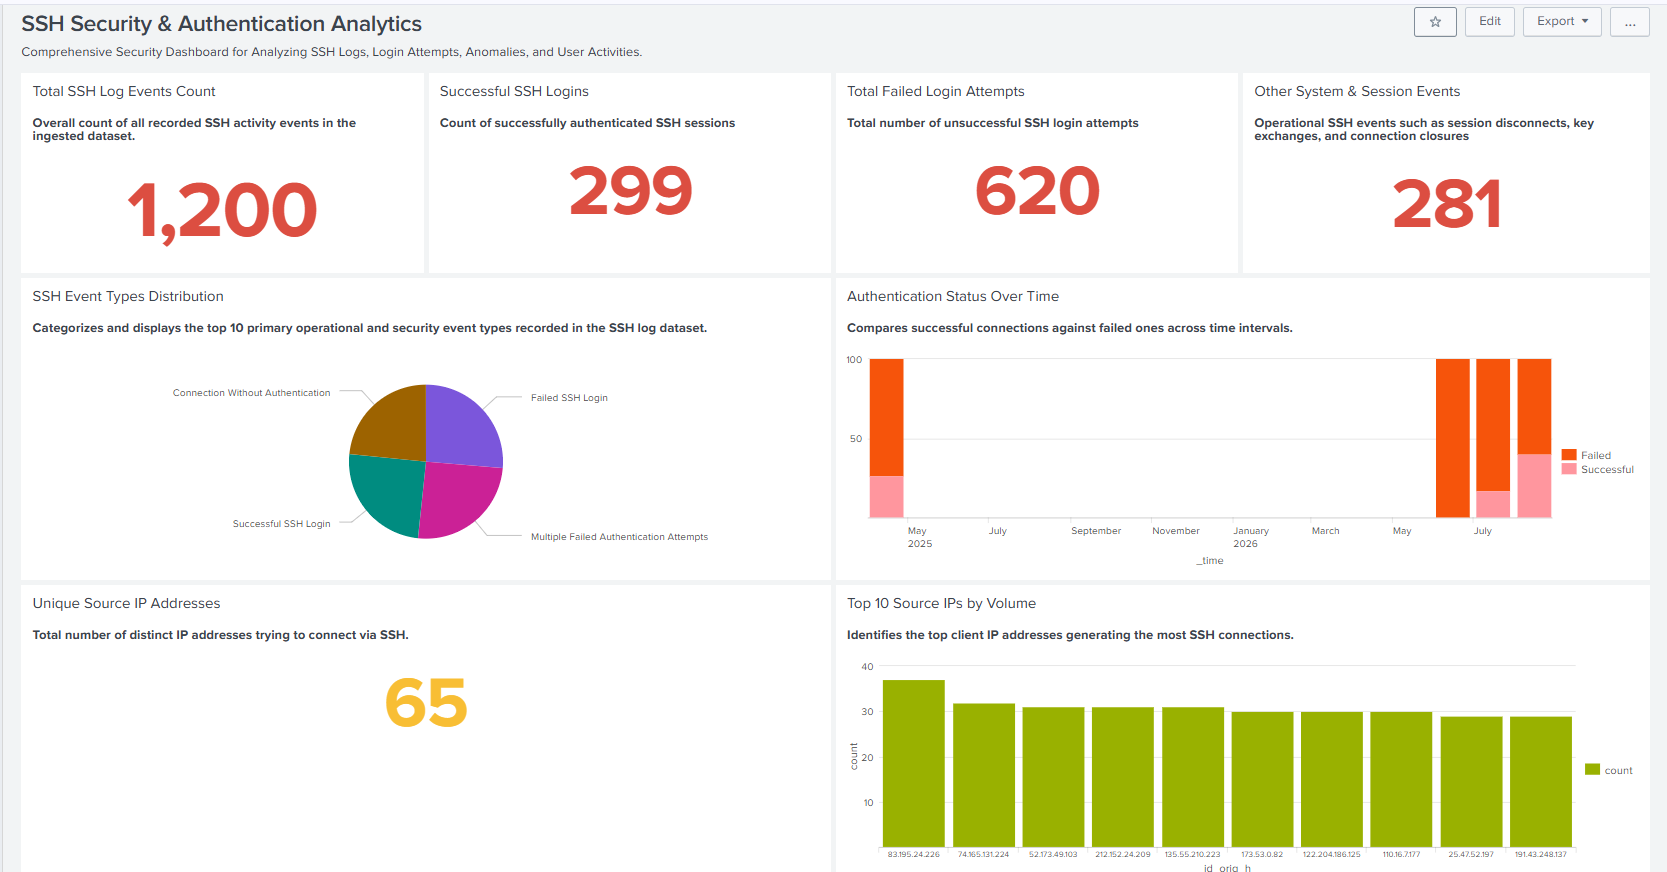

In [1]:
from IPython.display import Image

print("Dashboard_01: Overall SSH Activity Summary")
Image(filename='/content/Dashboard_01.png')

Dashboard_02: Source & Target Analysis


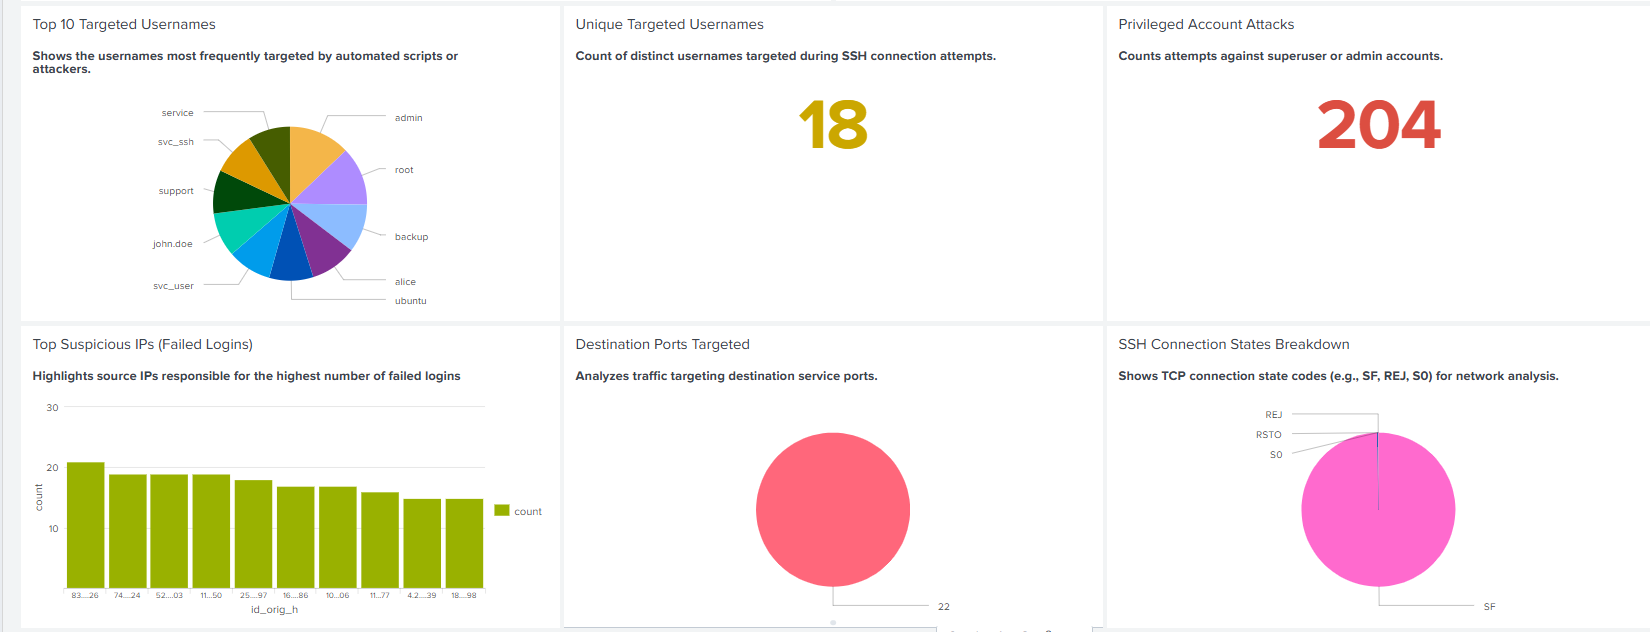

In [2]:
from IPython.display import Image

print("Dashboard_02: Source & Target Analysis")
Image(filename='/content/Dashboard_02.png')

Dashboard_03: Anomaly & Attack Detection


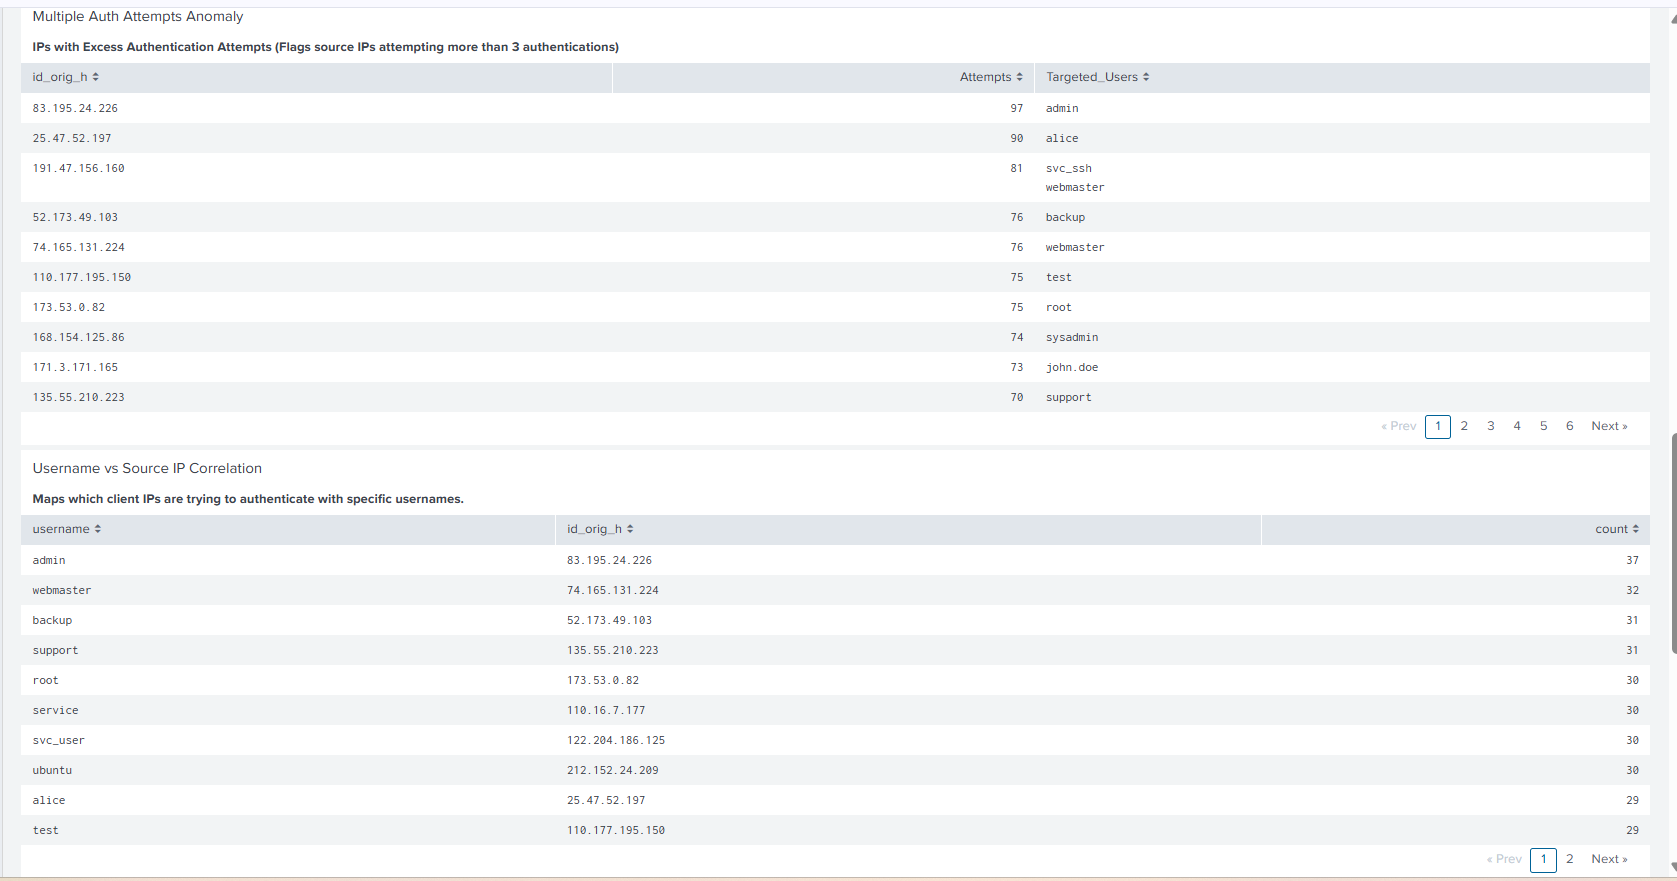

In [3]:
from IPython.display import Image

print("Dashboard_03: Anomaly & Attack Detection")
Image(filename='/content/Dashboard_03.png')

Dashboard_04: Geolocation & Failure Ratio


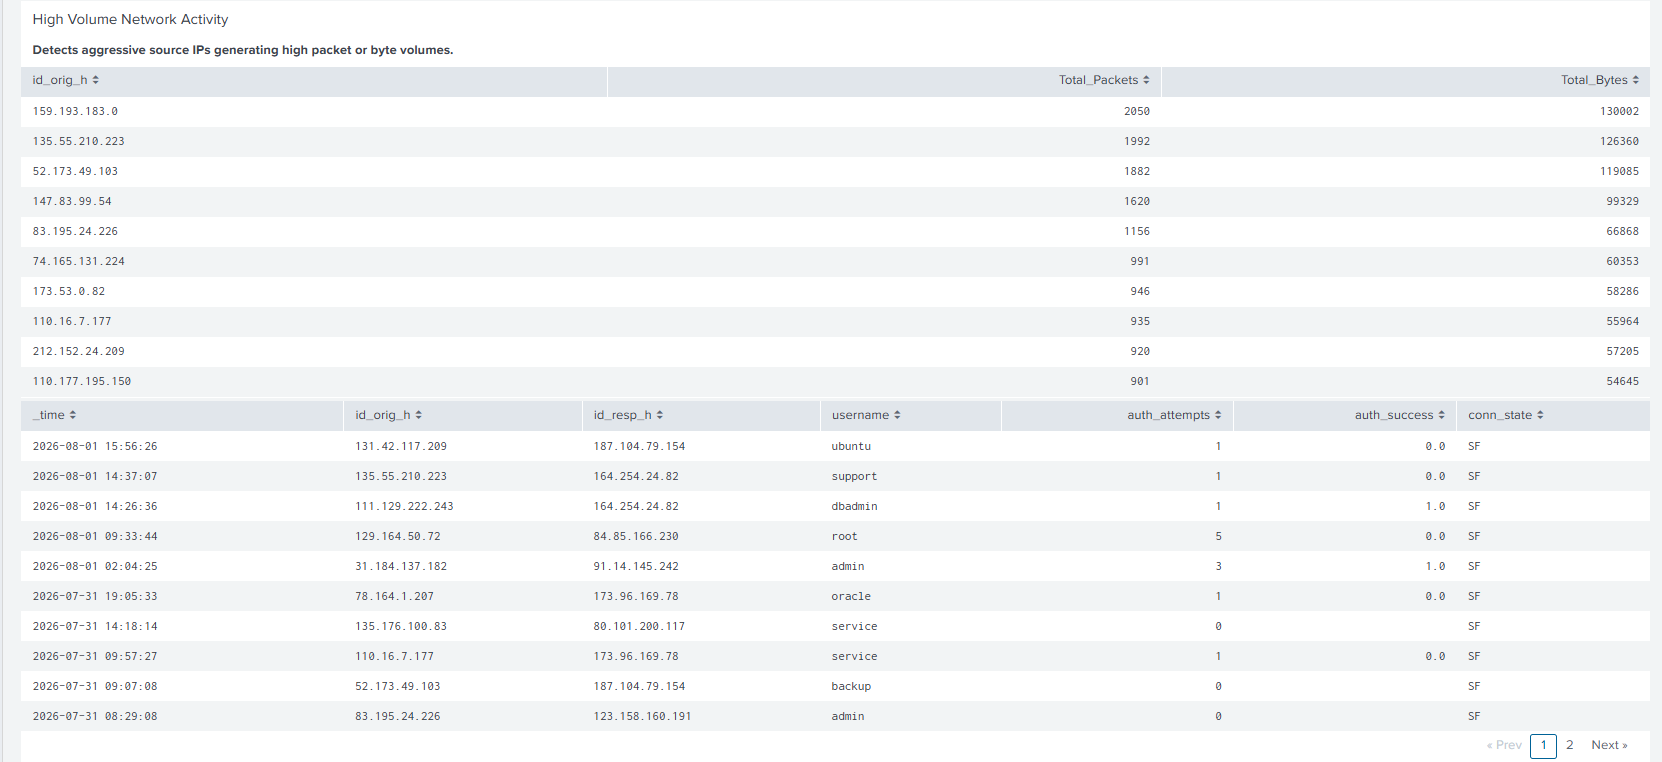

In [4]:
from IPython.display import Image

print("Dashboard_04: Geolocation & Failure Ratio")
Image(filename='/content/Dashboard_04.png')

## Splunk Security Alerts Configuration
To automate incident detection, 10 SOC Alerts were configured in Splunk. These alerts continuously evaluate log activity and trigger notifications when security thresholds are breached.

### Alert 01: SSH Brute-Force Attack Detected
*   **Title:** SSH Brute-Force Attack Detected
*   **Description:** Triggers when a single Source IP address accumulates 5 or more failed SSH login attempts within a designated evaluation window.
*   **SPL Query:**
```spl
index="ssh_logs" (auth_success="false" OR auth_success=0)
| stats count as failed_attempts by id_orig_h
| where failed_attempts >= 5
```

### Alert 02: Root Account Login Targeting
*   **Title:** Root Account Login Targeting
*   **Description:** Generates an immediate security alert whenever authentication attempts target the superuser root account.
*   **SPL Query:**
```spl
index="ssh_logs" username="root"
| stats count, values(id_orig_h) as source_ips by auth_success
```

### Alert 03: High Authentication Attempts Anomaly
*   **Title:** High Authentication Attempts Anomaly
*   **Description:** Flags connection sessions where a single client attempts more than 3 password credentials, indicating dictionary attacks.
*   **SPL Query:**
```spl
index="ssh_logs" auth_attempts > 3
| stats sum(auth_attempts) as total_attempts by id_orig_h, username
```

### Alert 04: Unusual Nighttime SSH Access
*   **Title:** Unusual Nighttime SSH Access
*   **Description:** Detects login attempts occurring during off-peak hours (between 12:00 AM and 05:00 AM).
*   **SPL Query:**
```spl
index="ssh_logs" (date_hour >= 0 AND date_hour <= 5)
| stats count by id_orig_h, username, auth_success
```

### Alert 05: Potential Password Spraying Attack
*   **Title:** Potential Password Spraying Attack
*   **Description:** Triggers when a single source IP attempts logins against more than 3 distinct username accounts.
*   **SPL Query:**
```spl
index="ssh_logs"
| stats dc(username) as distinct_users by id_orig_h
| where distinct_users > 3
```

### Alert 06: SSH Login Success After Failures
*   **Title:** SSH Login Success After Failures
*   **Description:** High-severity alert triggering when a source IP successfully authenticates after previously logging multiple failures (indicates potential account breach).
*   **SPL Query:**
```spl
index="ssh_logs"
| stats count(eval(auth_success="false" OR auth_success=0)) as Failures, count(eval(auth_success="true" OR auth_success=1)) as Successes by id_orig_h, username
| where Failures > 0 AND Successes > 0
```

### Alert 07: High Packet Count SSH Session
*   **Title:** High Packet Count SSH Session
*   **Description:** Identifies abnormally heavy network traffic sessions (>800 packets), signaling possible data exfiltration or automated fuzzing.
*   **SPL Query:**
```spl
index="ssh_logs" orig_pkts > 800
| stats sum(orig_pkts) as Total_Packets by id_orig_h, username
```

### Alert 08: Admin/Service Account Access Attempt
*   **Title:** Admin/Service Account Access Attempt
*   **Description:** Monitors and flags authentication attempts targeting sensitive service accounts (admin, webmaster, dbadmin, backup).
*   **SPL Query:**
```spl
index="ssh_logs" (username="admin" OR username="webmaster" OR username="dbadmin" OR username="backup")
| stats count by id_orig_h, username, auth_success
```

### Alert 09: Non-Authenticated SSH Connection Anomaly
*   **Title:** Non-Authenticated SSH Connection Anomaly
*   **Description:** Detects network connection sessions that terminate or drop before entering authentication phases.
*   **SPL Query:**
```spl
index="ssh_logs" conn_state!="SF" OR event_type="Connection Without Authentication"
| stats count by id_orig_h, conn_state
```

### Alert 10: Distributed SSH Connection Activity
*   **Title:** Distributed SSH Connection Activity
*   **Description:** Flags target server IPs receiving connection attempts from more than 10 unique source IP addresses, indicating distributed scanning.
*   **SPL Query:**
```spl
index="ssh_logs"
| stats dc(id_orig_h) as unique_attackers by id_resp_h
| where unique_attackers >= 10
```

## Security Incident Response Playbook: SSH Authentication Anomalies

This playbook outlines the recommended procedures for responding to various SSH security alerts generated by the Splunk SIEM. The goal is to provide clear, actionable steps for security analysts to investigate, contain, eradicate, and recover from potential SSH-related security incidents.

---

### Playbook Entry 01: SSH Brute-Force Attack Detected
*   **Alert:** `Alert 01: SSH Brute-Force Attack Detected`
*   **Trigger:** Single Source IP accumulates 5 or more failed SSH login attempts.
*   **Severity:** High
*   **Initial Actions:**
    1.  **Verify:** Confirm multiple failed login attempts from the identified `id_orig_h` in Splunk.
    2.  **Block:** Immediately block the `id_orig_h` at the firewall/network access control level.
    3.  **Investigate:** Check if any successful logins occurred from the `id_orig_h` before/after the brute-force attempts.
    4.  **Notify:** Inform the Incident Response Team and relevant system owners.

### Playbook Entry 02: Root Account Login Targeting
*   **Alert:** `Alert 02: Root Account Login Targeting`
*   **Trigger:** Authentication attempts target the `root` user account.
*   **Severity:** Critical
*   **Initial Actions:**
    1.  **Verify:** Confirm attempts against the `root` account and identify `id_orig_h` and `auth_success` status.
    2.  **Contain:** If successful, isolate the affected server. If failed, monitor `id_orig_h` closely.
    3.  **Investigate:** Determine if the attempts are legitimate (e.g., from an authorized administrator) or malicious.
    4.  **Escalate:** Immediately escalate to the Incident Response Team and CISO.

### Playbook Entry 03: High Authentication Attempts Anomaly
*   **Alert:** `Alert 03: High Authentication Attempts Anomaly`
*   **Trigger:** Single client attempts more than 3 password credentials within a session.
*   **Severity:** Medium to High
*   **Initial Actions:**
    1.  **Verify:** Review Splunk logs for `auth_attempts > 3` for the identified `id_orig_h` and `username`.
    2.  **Monitor:** Place `id_orig_h` under elevated monitoring for a defined period (e.g., 24-48 hours).
    3.  **Cross-reference:** Check `id_orig_h` against threat intelligence feeds.
    4.  **Recommend:** Advise users of targeted `username` to reset passwords if suspicious activity persists.

### Playbook Entry 04: Unusual Nighttime SSH Access
*   **Alert:** `Alert 04: Unusual Nighttime SSH Access`
*   **Trigger:** Login attempts during off-peak hours (12:00 AM - 05:00 AM).
*   **Severity:** Medium
*   **Initial Actions:**
    1.  **Verify:** Confirm `id_orig_h`, `username`, and `auth_success` status during off-peak hours.
    2.  **Contextualize:** Determine if the access is from a known administrator working off-hours or from an unexpected location.
    3.  **Contact User/Admin:** If `auth_success` is true, contact the `username` to verify legitimacy. If unverified, treat as suspicious.
    4.  **Review Policies:** Ensure policies regarding off-hours access are enforced and communicated.

### Playbook Entry 05: Potential Password Spraying Attack
*   **Alert:** `Alert 05: Potential Password Spraying Attack`
*   **Trigger:** Single source IP attempts logins against more than 3 distinct username accounts.
*   **Severity:** High
*   **Initial Actions:**
    1.  **Verify:** Confirm `id_orig_h` is attempting logins against multiple `distinct_users`.
    2.  **Block:** Temporarily block `id_orig_h` at the firewall/network edge.
    3.  **Audit:** Review authentication logs for any successful logins from the identified `id_orig_h` against *any* user.
    4.  **Force Password Reset:** For all accounts targeted by the `id_orig_h`, consider forcing a password reset and enabling MFA.

### Playbook Entry 06: SSH Login Success After Failures
*   **Alert:** `Alert 06: SSH Login Success After Failures`
*   **Trigger:** Source IP successfully authenticates after previously logging multiple failures.
*   **Severity:** Critical
*   **Initial Actions:**
    1.  **Verify:** Confirm both failed and successful logins for `id_orig_h` and `username`.
    2.  **Isolate/Contain:** If the source is external and the account is critical, consider isolating the user account and/or endpoint.
    3.  **Contact User:** Immediately contact the `username` to verify the legitimacy of the successful login. Assume compromise until proven otherwise.
    4.  **Investigate:** Perform a full forensic analysis of the `username`'s activity post-compromise.

### Playbook Entry 07: High Packet Count SSH Session
*   **Alert:** `Alert 07: High Packet Count SSH Session`
*   **Trigger:** Abnormally heavy network traffic sessions (>800 packets).
*   **Severity:** Medium
*   **Initial Actions:**
    1.  **Verify:** Confirm `orig_pkts > 800` for the identified `id_orig_h` and `username`.
    2.  **Monitor:** Deep dive into the session content if possible (e.g., using network flow data, packet captures if available and authorized) to identify data exfiltration or automated fuzzing tools.
    3.  **Review Context:** Is this a known automated process? If not, investigate further.
    4.  **Endpoint Scan:** Perform an endpoint scan on the client system if `id_orig_h` maps to an internal asset.

### Playbook Entry 08: Admin/Service Account Access Attempt
*   **Alert:** `Alert 08: Admin/Service Account Access Attempt`
*   **Trigger:** Authentication attempts target sensitive service accounts (admin, webmaster, dbadmin, backup).
*   **Severity:** High
*   **Initial Actions:**
    1.  **Verify:** Confirm attempts against sensitive accounts (`username`) and identify `id_orig_h` and `auth_success` status.
    2.  **Contextualize:** Determine if the access attempt is legitimate based on change management records or authorized personnel.
    3.  **If Suspicious:** Treat as `Alert 02` (Root Account Login Targeting) and follow similar escalation procedures.
    4.  **Review Account Privileges:** Ensure these accounts adhere to the principle of least privilege.

### Playbook Entry 09: Non-Authenticated SSH Connection Anomaly
*   **Alert:** `Alert 09: Non-Authenticated SSH Connection Anomaly`
*   **Trigger:** Network connection sessions that terminate or drop before authentication phases.
*   **Severity:** Low to Medium
*   **Initial Actions:**
    1.  **Verify:** Confirm `conn_state != "SF"` or `event_type="Connection Without Authentication"` for `id_orig_h`.
    2.  **Analyze Pattern:** Is this a single event or a continuous pattern? A pattern might indicate scanning or probing activity.
    3.  **Cross-reference:** Check `id_orig_h` against known malicious IPs. If internal, check for host issues.
    4.  **Block/Monitor:** For external IPs, consider blocking if persistent. For internal, investigate the client host.

### Playbook Entry 10: Distributed SSH Connection Activity
*   **Alert:** `Alert 10: Distributed SSH Connection Activity`
*   **Trigger:** Target server receives connection attempts from more than 10 unique source IP addresses.
*   **Severity:** Medium to High
*   **Initial Actions:**
    1.  **Verify:** Confirm `id_resp_h` is being targeted by `unique_attackers >= 10`.
    2.  **Identify Target:** Determine the purpose of the `id_resp_h` and its criticality.
    3.  **Analyze Source IPs:** Investigate the geographic distribution and reputation of the `id_orig_h` IPs.
    4.  **Implement Rate Limiting:** Apply rate limiting or IP reputation-based blocking on the targeted server or network perimeter.